In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn - model building
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, mean_squared_error, mean_absolute_error

In [2]:
# Loading dataset
df = pd.read_csv("Churn_Modelling.csv")

# first 5 rows
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## **Data Preprocessing Part 1**

In [3]:
# Shape
print(df.shape)

# Info
df.info()

# Checking null values
df.isnull().sum()


(10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [4]:
df.drop(columns=['RowNumber','CustomerId','Surname'], inplace=True)


## **Churn Count **    

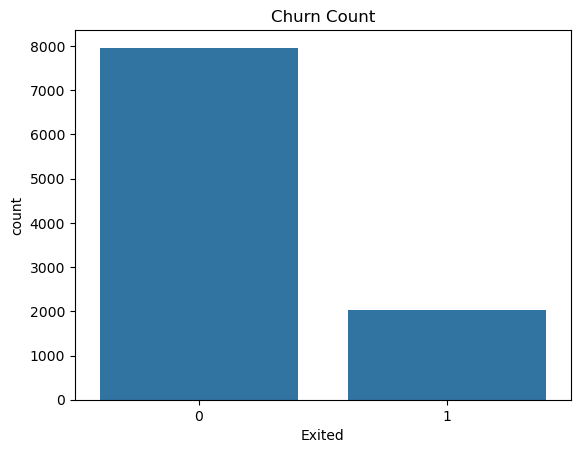

In [5]:
sns.countplot(x='Exited', data=df)
plt.title("Churn Count")
plt.show()


## **Exploratory Data Analysis**

Customer Demographics 

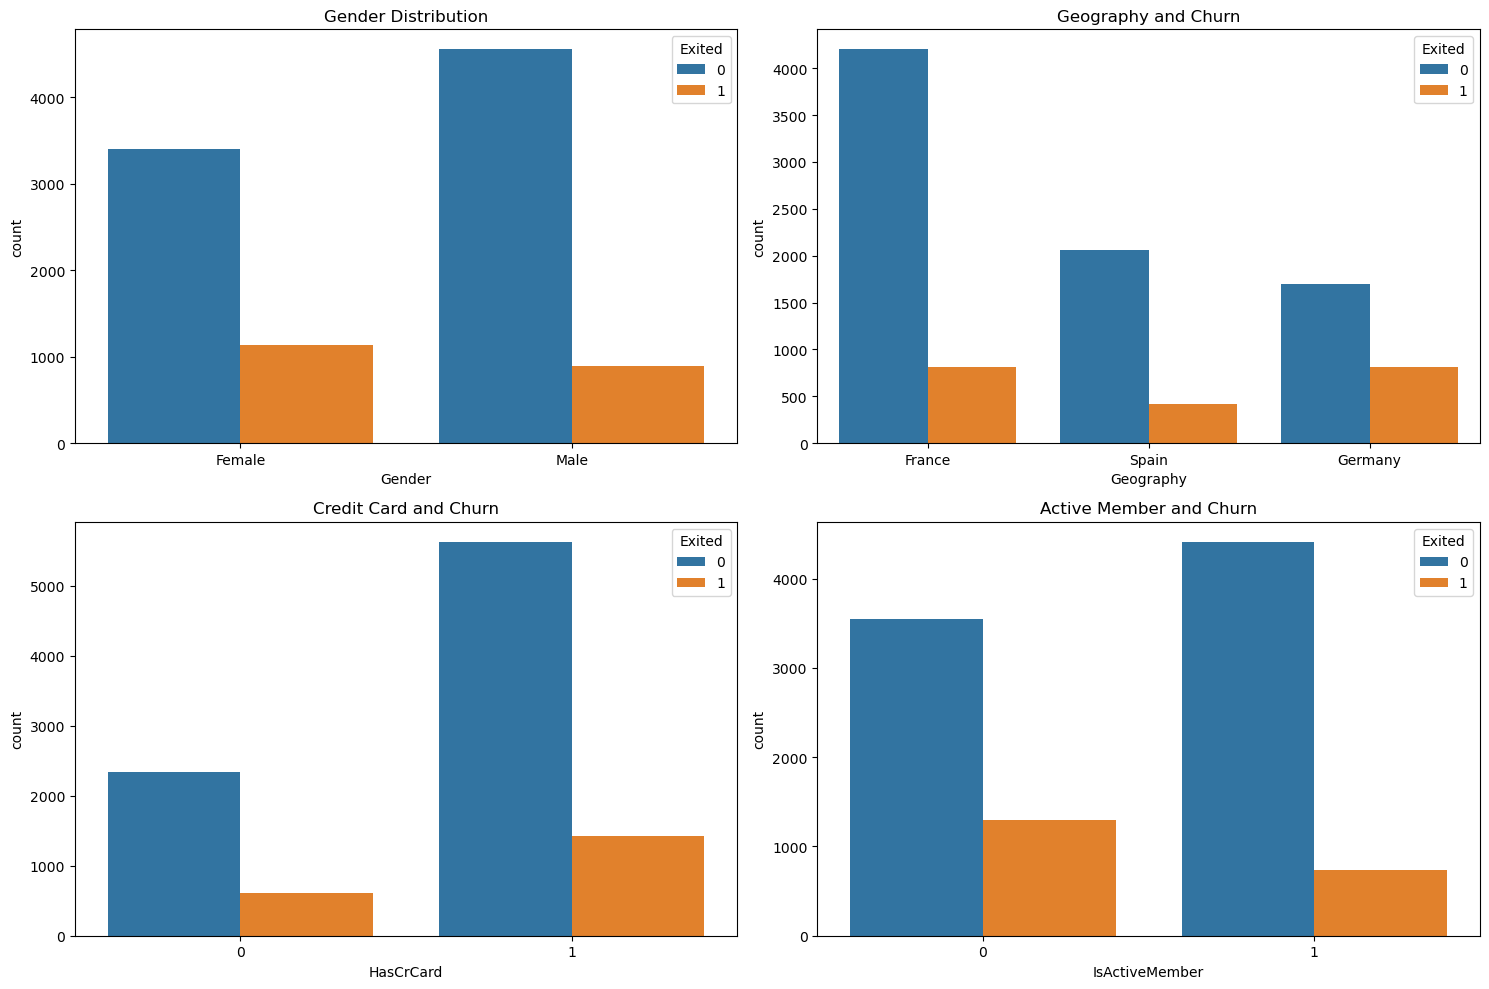

In [6]:
# Load dataset
df = pd.read_csv("Churn_Modelling.csv")

# Drop unnecessary columns
df.drop(['RowNumber','CustomerId','Surname'], axis=1, inplace=True)

# Create subplots
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# Gender Distribution
sns.countplot(x='Gender', data=df, hue='Exited', ax=ax[0,0])
ax[0,0].set_title('Gender Distribution')

# Geography Distribution
sns.countplot(x='Geography', data=df, hue='Exited', ax=ax[0,1])
ax[0,1].set_title('Geography and Churn')

# Has Credit Card
sns.countplot(x='HasCrCard', data=df, hue='Exited', ax=ax[1,0])
ax[1,0].set_title('Credit Card and Churn')

# Is Active Member
sns.countplot(x='IsActiveMember', data=df, hue='Exited', ax=ax[1,1])
ax[1,1].set_title('Active Member and Churn')

plt.tight_layout()
plt.show()

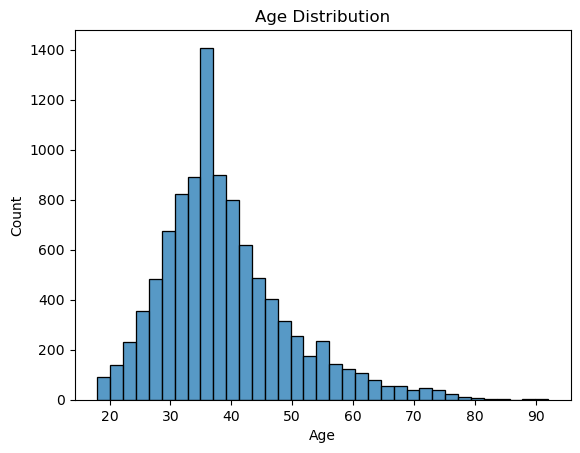

In [7]:
sns.histplot(df['Age'], bins=35)
plt.title("Age Distribution")
plt.show()


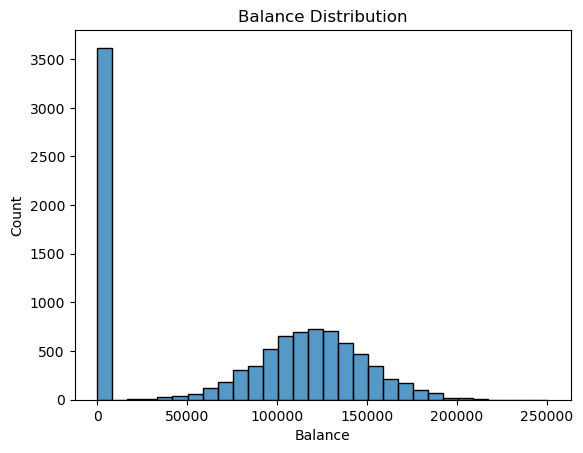

In [8]:
sns.histplot(df['Balance'], bins=30)
plt.title("Balance Distribution")
plt.show()


## **Correlation Matrix Heatmap**

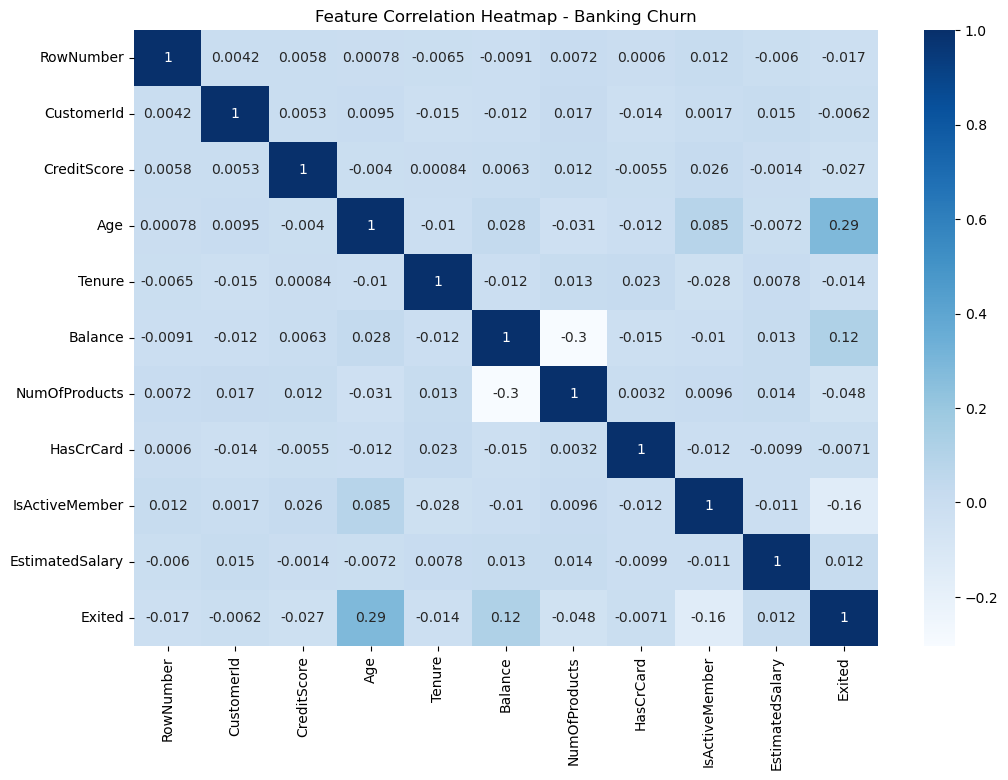

In [9]:
df = pd.read_csv("Churn_Modelling.csv")
# Correlation matrix
corr = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='Blues')

plt.title("Feature Correlation Heatmap - Banking Churn")
plt.show()

## **Billing/Charges and Churn**

Text(0.5, 1.0, 'Balance')

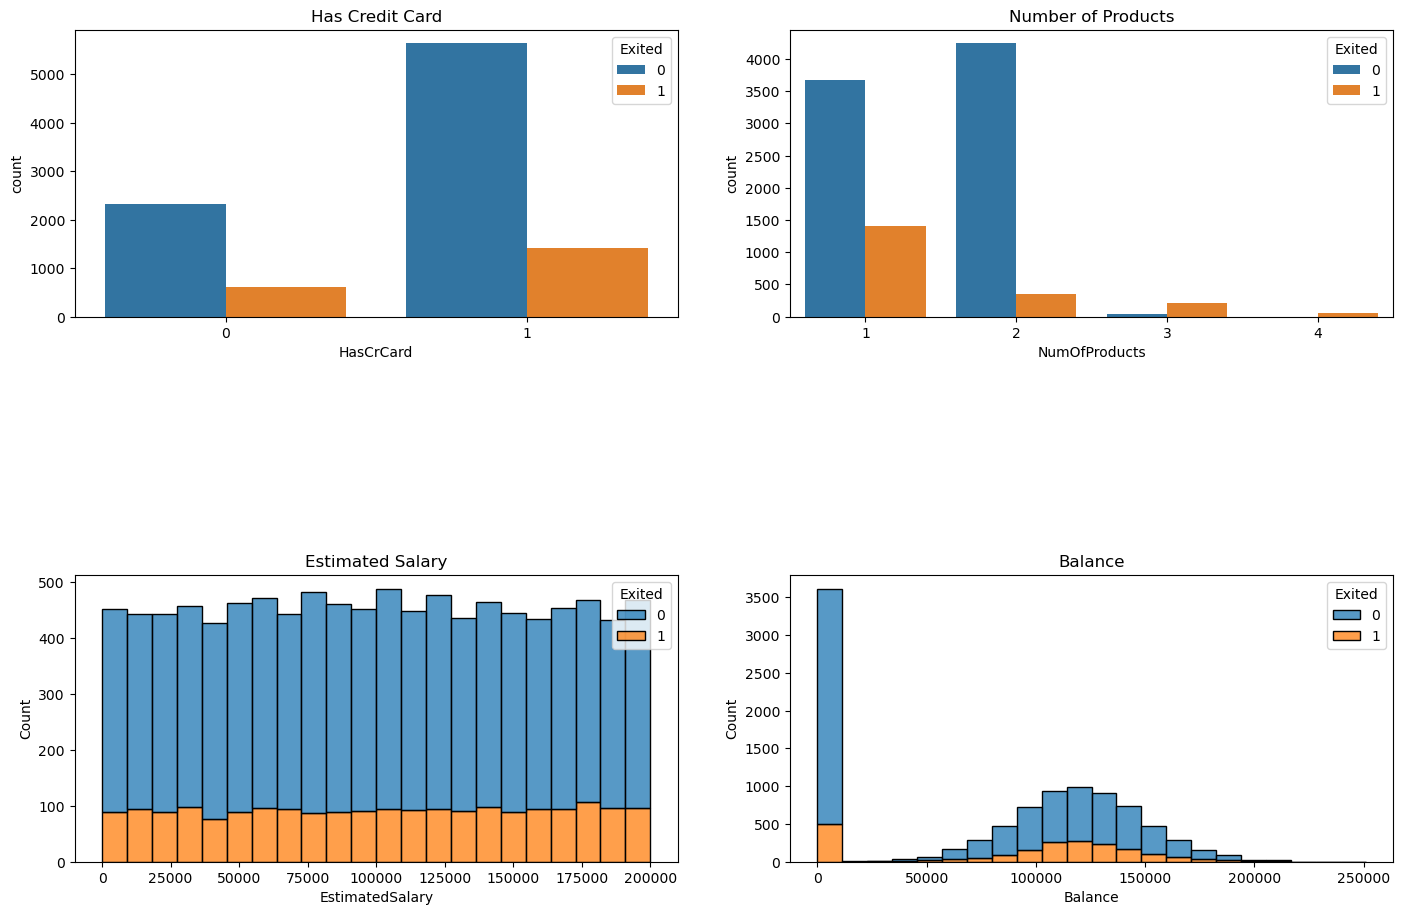

In [10]:
# Load dataset
df = pd.read_csv("Churn_Modelling.csv")

# Drop unnecessary columns
df.drop(['RowNumber','CustomerId','Surname'], axis=1, inplace=True)

# Create subplots
fig, ax = plt.subplots(2, 2, figsize=(15, 10))
fig.tight_layout(pad=5.0)

# spacing between plots
fig.subplots_adjust(hspace=0.9)

# Has Credit Card (like billing type)
sns.countplot(x='HasCrCard', data=df, ax=ax[0,0], hue='Exited').set_title('Has Credit Card')

# Payment behavior → NumOfProducts (closest alternative)
sns.countplot(x='NumOfProducts', data=df, ax=ax[0,1], hue='Exited').set_title('Number of Products')
ax[0,1].tick_params(axis='x', rotation=0)

# Monthly-like charges → Estimated Salary
sns.histplot(x='EstimatedSalary', data=df, ax=ax[1,0], hue='Exited', multiple='stack').set_title('Estimated Salary')

# Total balance → Balance
sns.histplot(x='Balance', data=df, ax=ax[1,1], hue='Exited', multiple='stack').set_title('Balance')

## **Label Encoding**

In [11]:
le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])

df['Geography'] = le.fit_transform(df['Geography'])


In [12]:
X = df.drop(columns='Exited')

y = df['Exited']


## **Train Test Split**

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


## **Feature Scaling**

In [14]:
sc = StandardScaler()

X_train = sc.fit_transform(X_train)

X_test = sc.transform(X_test)


## **Decision Tree Classifier**

In [15]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))


Decision Tree Accuracy: 0.7835


## **Random Forest Classifier**

In [16]:
rf = RandomForestClassifier(n_estimators=100)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))


Random Forest Accuracy: 0.8685


## **Knn Classifier**

In [17]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print("KNN Accuracy:",
      accuracy_score(y_test, knn_pred))


KNN Accuracy: 0.8355


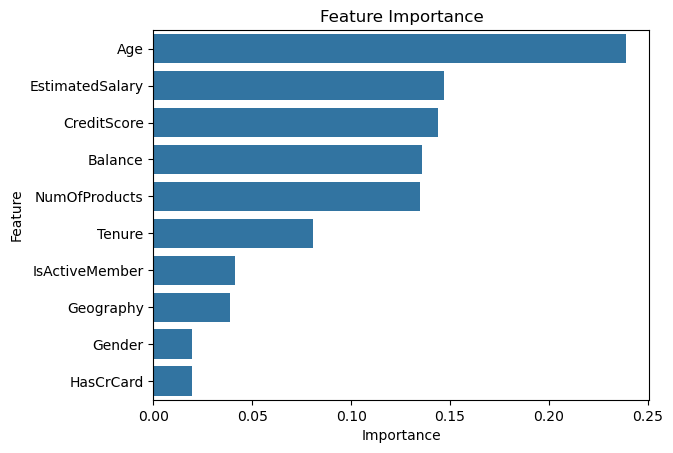

In [18]:
importance = rf.feature_importances_

feature_names = df.drop(columns='Exited').columns

feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_df = feature_df.sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feature_df)

plt.title("Feature Importance")
plt.show()


RANDOM FOREST CLASSIFIER_----------------------------------------------------------

In [19]:
# Create Random Forest model
rfc = RandomForestClassifier()

# Train model
rfc.fit(X_train, y_train)

# Training accuracy
print("Random Forest Training Accuracy:",
      rfc.score(X_train, y_train))

# Predict
r_pred = rfc.predict(X_test)


Random Forest Training Accuracy: 1.0


KNN CLASSIFIER

In [20]:
# Creating KNN model
knn = KNeighborsClassifier(n_neighbors=6)

# Train model
knn.fit(X_train, y_train)

# Training accuracy
print("KNN Training Accuracy:",
      knn.score(X_train, y_train))

# Predict
k_pred = knn.predict(X_test)


KNN Training Accuracy: 0.8605


CONFUSION MATRIX (ALL MODELS)


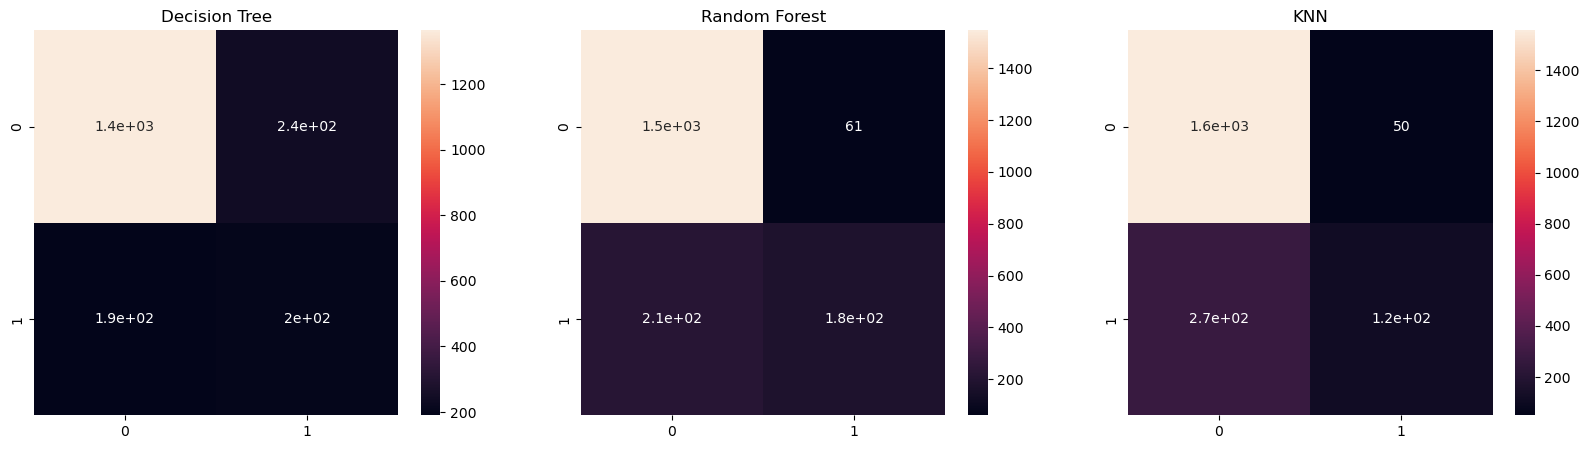

In [21]:
# Creating subplots
fig, ax = plt.subplots(1, 3, figsize=(20,5))

# Decision Tree
sns.heatmap(confusion_matrix(y_test, dt_pred),
            annot=True, ax=ax[0])
ax[0].set_title("Decision Tree")

# Random Forest
sns.heatmap(confusion_matrix(y_test, r_pred),
            annot=True, ax=ax[1])
ax[1].set_title("Random Forest")

# KNN
sns.heatmap(confusion_matrix(y_test, k_pred),
            annot=True, ax=ax[2])
ax[2].set_title("KNN")

plt.show()


CLASSIFICATION REPORT

In [22]:
print("Decision Tree Classification Report:\n",
      classification_report(y_test, dt_pred))

print("Random Forest Classification Report:\n",
      classification_report(y_test, r_pred))

print("KNN Classification Report:\n",
      classification_report(y_test, k_pred))


Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.85      0.86      1607
           1       0.46      0.52      0.48       393

    accuracy                           0.78      2000
   macro avg       0.67      0.68      0.67      2000
weighted avg       0.79      0.78      0.79      2000

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.46      0.57       393

    accuracy                           0.86      2000
   macro avg       0.81      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000

KNN Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.97      0.91      1607
           1       0.70      0.30      0.42       393

    accuracy                           0.84      2000
   macro avg       0.78 

MODEL PERFORMANCE COMPARISON

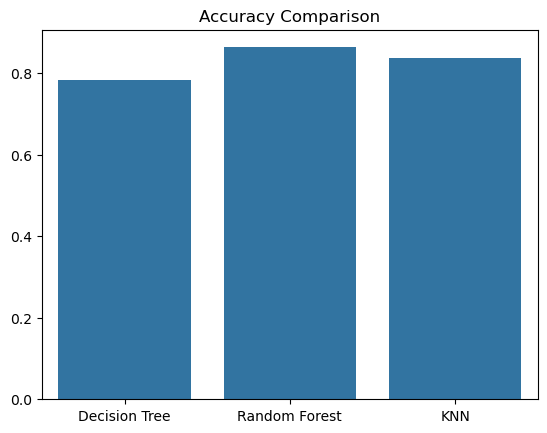

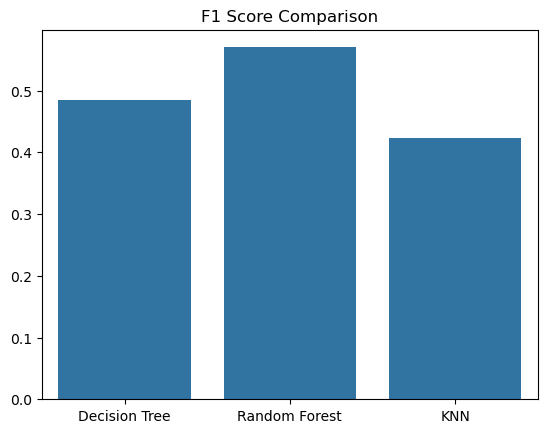

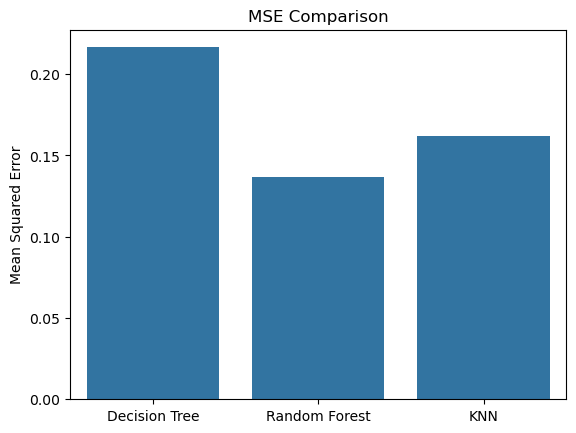

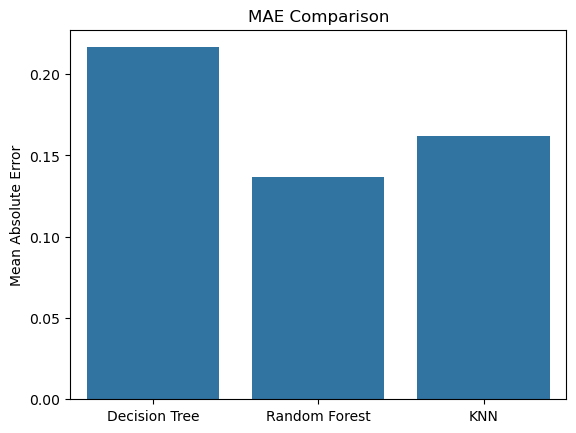

In [23]:
models = ['Decision Tree','Random Forest','KNN']

accuracy = [
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, r_pred),
    accuracy_score(y_test, k_pred)
]

f1 = [
    f1_score(y_test, dt_pred),
    f1_score(y_test, r_pred),
    f1_score(y_test, k_pred)
]

mse = [
    mean_squared_error(y_test, dt_pred),
    mean_squared_error(y_test, r_pred),
    mean_squared_error(y_test, k_pred)
]

mae = [
    mean_absolute_error(y_test, dt_pred),
    mean_absolute_error(y_test, r_pred),
    mean_absolute_error(y_test, k_pred)
]

# Accuracy Graph Plot
sns.barplot(x=models, y=accuracy)
plt.title("Accuracy Comparison")
plt.show()

# F1 Score Graph Plot
sns.barplot(x=models, y=f1)
plt.title("F1 Score Comparison")
plt.show()

# MSE Graph Plot
sns.barplot(x=models, y=mse)
plt.title("MSE Comparison")
plt.ylabel("Mean Squared Error")
plt.show()

# MAE Graph Plot
sns.barplot(x=models, y=mae)
plt.title("MAE Comparison")
plt.ylabel("Mean Absolute Error")
plt.show()


In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Predictions
y_pred_lr = rf.predict(X_test)

# Metrics
print("=== BANKING CHURN - LOGISTIC REGRESSION ===")
print("Accuracy  :", accuracy_score(y_test, y_pred_lr))
print("Precision :", precision_score(y_test, y_pred_lr))
print("Recall    :", recall_score(y_test, y_pred_lr))
print("F1 Score  :", f1_score(y_test, y_pred_lr))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

=== BANKING CHURN - LOGISTIC REGRESSION ===
Accuracy  : 0.8685
Precision : 0.7708333333333334
Recall    : 0.4707379134860051
F1 Score  : 0.584518167456556

Confusion Matrix:
 [[1552   55]
 [ 208  185]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.77      0.47      0.58       393

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.75      2000
weighted avg       0.86      0.87      0.86      2000



In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Predictions
y_pred_rf = rf.predict(X_test)

# Metrics
print("=== BANKING CHURN - RANDOM FOREST ===")
print("Accuracy  :", accuracy_score(y_test, y_pred_rf))
print("Precision :", precision_score(y_test, y_pred_rf))
print("Recall    :", recall_score(y_test, y_pred_rf))
print("F1 Score  :", f1_score(y_test, y_pred_rf))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

=== BANKING CHURN - RANDOM FOREST ===
Accuracy  : 0.8685
Precision : 0.7708333333333334
Recall    : 0.4707379134860051
F1 Score  : 0.584518167456556

Confusion Matrix:
 [[1552   55]
 [ 208  185]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.77      0.47      0.58       393

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.75      2000
weighted avg       0.86      0.87      0.86      2000

